In [1]:
import baltic as bt
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict
import statistics
import numpy as np
from scipy.optimize import minimize, LinearConstraint
import warnings
from datetime import datetime
import re
from treetime import TreeTime, TreeTimeError, utils
from dendropy import Tree
from Bio import SeqIO
import random
import math
import scipy.stats as stats

In [2]:
tree = 'trees/h3nx/summary_baltic.nwk'
traits_file = 'trees/h3nx/traits.json'

with open(traits_file) as f:
    traits = json.load(f)

mytree= bt.loadNewick(tree, absoluteTime= False)
node_traits = traits["nodes"]

total_host_switch = 0
host_switch_pairs = defaultdict(int)

for k in mytree.Objects:
    
    name = k.traits["label"] if k.is_node() else k.name
    
    k.traits["host"] = node_traits[name]["host"].lower()
    
for k in mytree.Objects:

    if k.is_node() and k.parent.traits != {} and k.parent.traits['host'] != k.traits['host']:
        
        total_host_switch+=1
        
        parent_host = "mammal" if k.parent.traits['host'] != "avian" else "avian"
        k_host = "mammal" if k.traits['host'] != "avian" else "avian"
    
        host_switch_pairs[(parent_host, k_host)] += 1
    

In [3]:
total_host_switch

47

In [4]:
host_switch_pairs

defaultdict(int,
            {('avian', 'mammal'): 6,
             ('mammal', 'mammal'): 33,
             ('mammal', 'avian'): 8})

# Nodes only, checking parent

In [5]:
# only nodes, checking parent 

host_switch_rea = no_switch_rea = 0
host_switch_clonal = no_switch_clonal = 0

host_switches = {}

for k in mytree.Objects:
    
    if k.is_node() and  k.traits['is_reassorted']:
        
        if k.parent.traits['host'] == k.traits['host']:
            no_switch_rea += 1

        else:
            host_switch_rea += 1
            host_switches[(k.parent.traits['host'], k.traits['host'])] = host_switches.get((k.parent.traits['host'], k.traits['host']), 0) + 1
            
    
    if k.is_node() and k.parent.traits and not k.traits['is_reassorted']:
              
        if k.parent.traits['host'] == k.traits['host']:
            no_switch_clonal += 1
            
        else:
            host_switch_clonal += 1
    

In [6]:
host_switches

{('avian', 'seal'): 1,
 ('avian', 'human'): 1,
 ('human', 'swine'): 17,
 ('swine', 'human'): 1,
 ('swine', 'avian'): 1}

In [7]:
host_switches_simplified = {}

for (from_host, to_host), count in host_switches.items():

    from_label = from_host if from_host == "avian" else "mammal"
    to_label = to_host if to_host == "avian" else "mammal"

    key = (from_label, to_label)
    host_switches_simplified[key] = host_switches_simplified.get(key, 0) + count

print(host_switches_simplified)

{('avian', 'mammal'): 2, ('mammal', 'mammal'): 18, ('mammal', 'avian'): 1}


In [8]:
print(host_switch_rea, no_switch_rea)
print(host_switch_clonal, no_switch_clonal)

21 776
26 5279


In [9]:
# fitness analysis FET

p_values = []
odds_ratios = []
confidence = []

a = host_switch_rea
b = no_switch_rea
c = host_switch_clonal
d = no_switch_clonal

table = [[a, b], [c, d]]

odds_ratio, p_value = stats.fisher_exact(table, alternative='two-sided')

if a > 0 and b > 0 and c > 0 and d > 0:
    se_log_or = math.sqrt(1/a + 1/b + 1/c + 1/d)
    log_or = math.log(odds_ratio)
    ci_low = math.exp(log_or - 1.96 * se_log_or)
    ci_high = math.exp(log_or + 1.96 * se_log_or)
else:
    print(f"one of your counts are 0")
    ci_low, ci_high = float('nan'), float('nan')

odds_ratios.append(odds_ratio)
p_values.append(p_value)
confidence.append((ci_low, ci_high))

print(f"p-value = {p_value:.10f}, odds ratio = {odds_ratio:.2f}, 95% CI = {ci_low, ci_high}")

p-value = 0.0000000934, odds ratio = 5.49, 95% CI = (3.0765079316596227, 9.813269725015772)


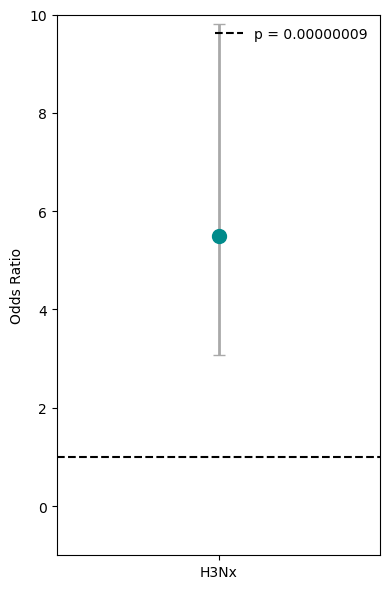

In [10]:
fig, axes = plt.subplots(1,1, figsize=(4,6))


#  error bars
lower_err = odds_ratio - ci_low
upper_err = ci_high - odds_ratio
error_bars = [[lower_err], [upper_err]]

axes.errorbar(
    [0], [odds_ratio],
    yerr=error_bars,
    fmt='o',
    color='darkcyan',
    ecolor='darkgrey',
    elinewidth=2,
    capsize=4,
    markersize=10
)

axes.axhline(1, color='black', linestyle='--')

axes.set_xticks([0])
axes.set_xticklabels(["H3Nx"])
axes.legend([f"p = {p_value:.8f}"], loc='upper right', frameon=False)

axes.set_ylabel("Odds Ratio")
x_margin = 0.2
axes.set_xlim(-0.2, 0.2)
axes.set_ylim(-1, 10) 

plt.savefig(f"plots/H3Nx_OR.pdf", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()


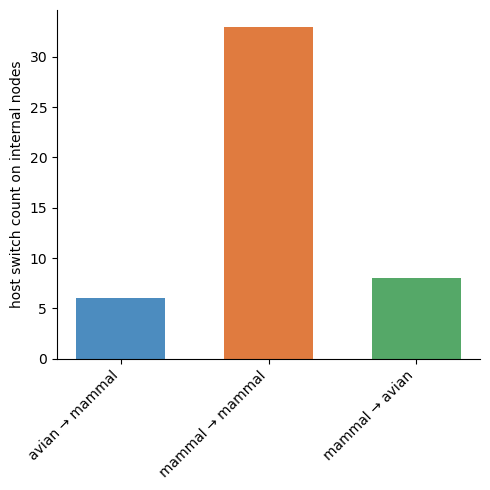

In [11]:
categories = [
    ('avian','mammal'),
    ('mammal','mammal'),
    ('mammal','avian')
]

labels = [
    "avian → mammal",
    "mammal → mammal",
    "mammal → avian"
]


colors = ["#4C8CBF", "#E07B3F", "#55A868"]  # muted blue, orange, green

total_vals = [host_switch_pairs.get(c,0) for c in categories]


x = np.arange(len(categories))
width = 0.6

fig, ax = plt.subplots(figsize=(5,5))


ax.bar(
    x,
    total_vals,
    width,
    color= colors,
    linewidth=1.5,
    label="all host switches"
)


ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel("host switch count on internal nodes")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')

# ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(f"plots/all_host_switches.pdf", dpi=300, bbox_inches="tight")
plt.show()

# nodes and leaves, checking parent

In [12]:
# only nodes, checking parent 

host_switch_rea = no_switch_rea = 0
host_switch_clonal = no_switch_clonal = 0

for k in mytree.Objects:
    
    if k.traits['is_reassorted']:
        
        if k.parent.traits['host'] == k.traits['host']:
            no_switch_rea += 1
            
        else:
            host_switch_rea += 1
    
    if k.parent.traits and not k.traits['is_reassorted']:
              
        if k.parent.traits['host'] == k.traits['host']:
            no_switch_clonal += 1
            
        else:
            host_switch_clonal += 1
    

In [13]:
print(host_switch_rea, no_switch_rea)
print(host_switch_clonal, no_switch_clonal)

35 1664
64 10443


In [14]:
# fitness analysis FET

p_values = []
odds_ratios = []
confidence = []

a = host_switch_rea
b = no_switch_rea
c = host_switch_clonal
d = no_switch_clonal

table = [[a, b], [c, d]]

odds_ratio, p_value = stats.fisher_exact(table, alternative='two-sided')

if a > 0 and b > 0 and c > 0 and d > 0:
    se_log_or = math.sqrt(1/a + 1/b + 1/c + 1/d)
    log_or = math.log(odds_ratio)
    ci_low = math.exp(log_or - 1.96 * se_log_or)
    ci_high = math.exp(log_or + 1.96 * se_log_or)
else:
    print(f"one of your counts are 0")
    ci_low, ci_high = float('nan'), float('nan')

odds_ratios.append(odds_ratio)
p_values.append(p_value)
confidence.append((ci_low, ci_high))

print(f"p-value = {p_value:.8f}, odds ratio = {odds_ratio:.2f}, 95% CI = {ci_low, ci_high}")

p-value = 0.00000006, odds ratio = 3.43, 95% CI = (2.2657088548413054, 5.198953712919934)


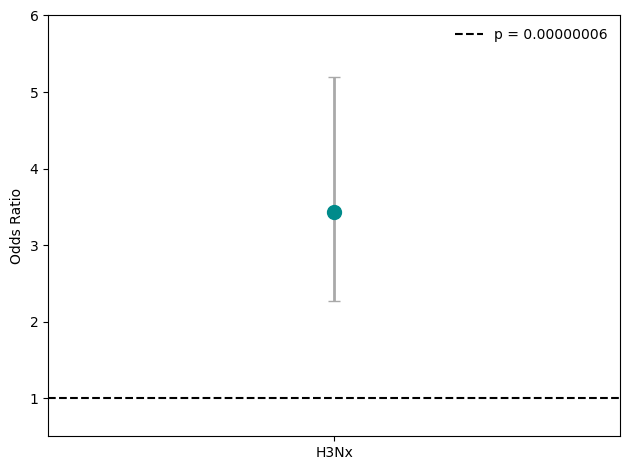

In [15]:
fig, axes = plt.subplots(1,1)


#  error bars
lower_err = odds_ratio - ci_low
upper_err = ci_high - odds_ratio
error_bars = [[lower_err], [upper_err]]

axes.errorbar(
    [0], [odds_ratio],
    yerr=error_bars,
    fmt='o',
    color='darkcyan',
    ecolor='darkgrey',
    elinewidth=2,
    capsize=4,
    markersize=10
)

axes.axhline(1, color='black', linestyle='--')

axes.set_xticks([0])
axes.set_xlim(-1, 1)
axes.set_xticks([0])
axes.set_ylim(0.5, 6)
axes.set_xticklabels(["H3Nx"])
axes.legend([f"p = {p_value:.8f}"], loc='upper right', frameon=False)

axes.set_ylabel("Odds Ratio")

plt.tight_layout()
plt.show()


# making table of reassorting segmented implicated in a host switch

In [16]:
rows = []

for k in mytree.Objects:
    
    name = k.name if k.is_leaf() else k.traits['label']
    type = "leaf" if k.is_leaf() else "node"
    
    if k.traits['is_reassorted']:
        
        if k.parent.traits['host'] == k.traits['host']:
            continue
            
        else:
            raw_segments = k.traits["rea"]
            lst = [seg.split("(")[0].lstrip('_') for seg in raw_segments.split("-")]
            parent_host = k.parent.traits['host']
            switched_host = k.traits["host"]
            
            rows.append({
            "name": name,
            "segments": lst,
            "type": type,
            "host switch": f"{parent_host} --> {switched_host}"    
            })
            # add name df to table, if k.is_node() or k.is_leaf(), and the segments in k.traits['rea']
            
df = pd.DataFrame(rows)
    

In [17]:
# Filter for nodes only
node_df = df[df['type'] == 'node']
print(node_df)

# Value counts for all host switches (entire df)
print(node_df['host switch'].value_counts())

            name                        segments  type      host switch
1   TS_NODE_1376                            [PA]  node   avian --> seal
6   TS_NODE_6096                            [NP]  node  avian --> human
7   TS_NODE_3005           [MP, NP, NS, PA, PB2]  node  human --> swine
8   TS_NODE_3035                            [NS]  node  human --> swine
9   TS_NODE_3292                            [NS]  node  human --> swine
12  TS_NODE_4651                            [NA]  node  swine --> human
13  TS_NODE_3656           [MP, NP, NS, PA, PB2]  node  human --> swine
14  TS_NODE_3921  [MP, NA, NP, NS, PA, PB1, PB2]  node  human --> swine
15  TS_NODE_3864               [MP, NA, NP, PB1]  node  swine --> avian
18  TS_NODE_4109      [MP, NP, NS, PA, PB1, PB2]  node  human --> swine
19  TS_NODE_4192      [MP, NP, NS, PA, PB1, PB2]  node  human --> swine
21  TS_NODE_4318                            [NA]  node  human --> swine
23  TS_NODE_4467                            [NA]  node  human --

In [18]:
df

,name,segments,type,host switch
0,A/seal/Massachusetts/3911/1992|1992-01-01,[NS],leaf,avian --> seal
1,TS_NODE_1376,[PA],node,avian --> seal
2,A/Phoca_vitulina/Alaska/PV2114/2021|2021-08-24,[NA],leaf,avian --> seal
3,A/swine/Kazakhstan/106/1985|1985-01-01,"[NA, NS]",leaf,avian --> swine
4,A/Changsha/1000/2022|2022-05-11,[PB1],leaf,avian --> human
5,A/Felis_catus/USA/047732/2018|2018-03-27,"[MP, NP, NS, PA, PB1, PB2]",leaf,canine --> feline
6,TS_NODE_6096,[NP],node,avian --> human
7,TS_NODE_3005,"[MP, NP, NS, PA, PB2]",node,human --> swine
8,TS_NODE_3035,[NS],node,human --> swine
9,TS_NODE_3292,[NS],node,human --> swine


In [19]:
df.to_csv("plots/reassorted_segments_all.csv", index=False)

In [20]:
# subsetting
df_leaves = df[df['type'] == 'leaf'].copy()
df_nodes = df[df['type'] == 'node'].copy()

df_leaves.to_csv("plots/reassorted_segments_leaves.csv", index=False)
df_nodes.to_csv("plots/reassorted_segments_nodes.csv", index=False)
